# NBOW + Logistic Regression

TF-IDF bag-of-words features + logistic regression. The strong non-neural baseline.

**Dependencies:** Run `preprocessing.ipynb` first to produce `data/train_split.csv`, `val_split.csv`, `test_split.csv`.

**Outputs produced by this notebook:**
- `results/nbow_lr_results.json` — test set metrics 
- `results/test_nbow_lr_preds.csv` — test predictions 
- `results/errors_nbow_fp.csv` / `errors_nbow_fn.csv` — error samples for annotation
- `results/nbow_lr_cv_results.png` — cross-validation chart
- `results/nbow_lr_top_features.png` — feature importance chart
- `results/nbow_lr_ablation.png` / `nbow_lr_ablation.csv` — ablation results
- `results/nbow_lr_threshold_curve.png` — threshold tuning chart
- `models/tfidf_vectorizer.pkl` + `models/logistic_regression.pkl` — saved model

In [1]:
import sys, os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_splits, split_summary, class_weight_dict
from src.nbow_lr import (
    build_vectorizer, vectorize_splits,
    train_lr, plot_cv_results,
    get_top_features, print_top_features, plot_top_features,
    run_ablation, plot_ablation,
    tune_threshold, plot_threshold_curve,
    save_model, load_model,
)
from src.evaluation import evaluate, extract_errors

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("Imports OK")


Imports OK


## 1. Load data

In [2]:
train, val, test = load_splits('../data')
split_summary(train, val, test)


--------------------------------------------------
Split         Total    Toxic  Non-toxic    Toxic %
--------------------------------------------------
Train       127,644   12,980    114,664     10.17%
Val          15,955    1,622     14,333     10.17%
Test         15,958    1,623     14,335     10.17%
--------------------------------------------------
Total       159,557   16,225    143,332     10.17%

Imbalance: 8.8:1  (non-toxic : toxic)


In [9]:
# Confirm clean_text column exists — produced by preprocessing.ipynb
assert 'clean_text' in train.columns, "Run preprocessing.ipynb first!"
assert 'clean_text' in val.columns
assert 'clean_text' in test.columns

print("Columns:", list(train.columns))
print()
print("Sample cleaned comment:")
print(train.loc[train['label']==1, 'clean_text'].iloc[0])


Columns: ['id', 'comment_text', 'label', 'clean_text']

Sample cleaned comment:
racist man fuck u nigga i am black do u even know what the difference between the er and a is bitch motherfucka yre u feelin offended i bet u aint even black and if yeah than yall is oreo cookies anywayz im pure chocolate fool


## 2. Vectorization

TF-IDF converts each comment into a sparse vector of weighted word/bigram frequencies.

**Key parameter choices:**
- `ngram_range=(1,2)` — unigrams + bigrams capture phrases like "go die", "shut up"
- `max_features=50_000` — caps vocabulary; the long tail of rare tokens adds noise
- `sublinear_tf=True` — log-scales term frequencies so repetition isn't over-rewarded
- `min_df=3` — drops terms appearing in <3 documents (typos, one-off tokens)

The vectorizer is fit only on the training split. Fitting on val/test would leak their vocabulary into the model.

In [10]:
X_train, X_val, X_test, vectorizer = vectorize_splits(train, val, test)


Fitting TF-IDF vectorizer on training split only ...
  Vocabulary size : 50,000
  X_train shape   : (127644, 50000)
  X_val shape     : (15955, 50000)
  X_test shape    : (15958, 50000)
  Matrix density  : 0.00156


In [11]:
vocab = vectorizer.vocabulary_                     # token → column index
idf   = vectorizer.idf_                            # IDF weights per feature
feat_names = vectorizer.get_feature_names_out()

# Low IDF = common token (appears in many docs)
# High IDF = rare/specific token
idf_df = pd.DataFrame({'feature': feat_names, 'idf': idf})

print("10 most common tokens (lowest IDF — appear in many comments):")
print(idf_df.nsmallest(10, 'idf')[['feature','idf']].to_string(index=False))
print()
print("10 rarest tokens (highest IDF — appear in few comments):")
print(idf_df.nlargest(10, 'idf')[['feature','idf']].to_string(index=False))


10 most common tokens (lowest IDF — appear in many comments):
feature      idf
    the 1.398832
     to 1.523255
     is 1.600515
      i 1.628114
      a 1.659522
    and 1.683875
     of 1.735089
    you 1.747436
    not 1.817245
     it 1.842593

10 rarest tokens (highest IDF — appear in few comments):
      feature       idf
       118 61 11.370714
    2006 hist 11.370714
      2010 02 11.370714
    2013 diff 11.370714
        42 11 11.370714
        71 15 11.370714
       79 118 11.370714
    a dipshit 11.370714
       a pedo 11.370714
abusing power 11.370714


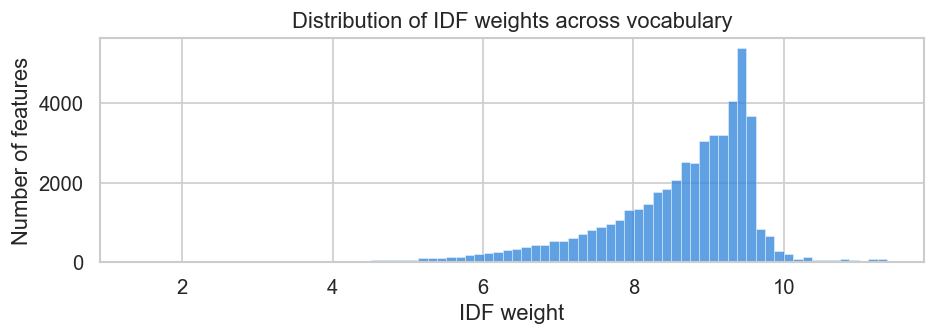

Most features cluster at high IDF (rare) — expected for natural language.


In [12]:
# Distribution of IDF weights
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(idf, bins=80, color='#378ADD', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel('IDF weight')
ax.set_ylabel('Number of features')
ax.set_title('Distribution of IDF weights across vocabulary')
plt.tight_layout()
plt.savefig('../results/nbow_lr_idf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Most features cluster at high IDF (rare) — expected for natural language.")


## 3. Training with cross-validation

Logistic regression has one key hyperparameter: **C** (inverse regularisation strength).
- Small C → strong regularisation → simpler model, may underfit
- Large C → weak regularisation → complex model, may overfit

We search over C = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0] using 5-fold stratified CV.

`class_weight='balanced'` automatically upweights the minority toxic class by ~9x.

In [13]:
best_lr, grid = train_lr(X_train, train['label'])



Running 5-fold cross-validation over C=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0] ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Grid search complete.
  Best C     : 1000.0
  Best val F1: 0.7822

Full CV results:
      C  mean_val_f1  std_val_f1  mean_train_f1
   0.01     0.614371    0.005828       0.623355
   0.10     0.675350    0.005953       0.703902
   1.00     0.751121    0.003445       0.836018
  10.00     0.775034    0.004193       0.906982
 100.00     0.778869    0.004964       0.942642
1000.00     0.782151    0.006115       0.933377


CV results plot saved to /Users/tuqa/4650/final project/toxic-classification/results/nbow_lr_cv_results.png


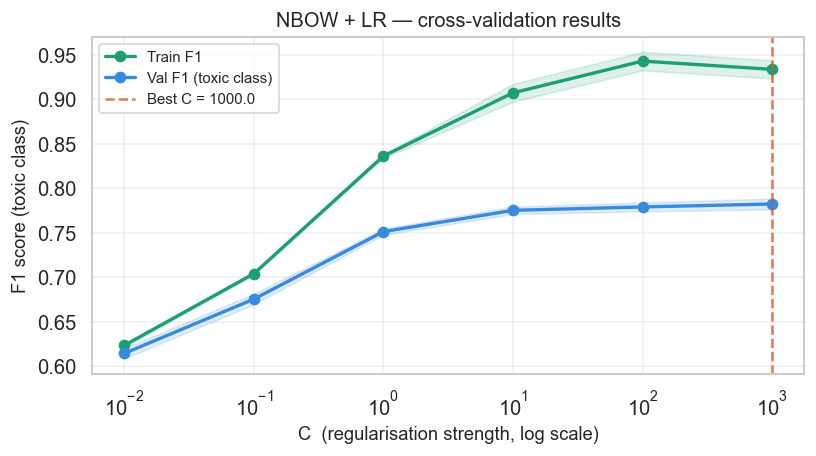

In [14]:
plot_cv_results(grid)


In [15]:
# Show the gap between train and val F1 for each C value
# A large gap = overfitting at that C value
cv_results = pd.DataFrame(grid.cv_results_)
print("Train vs Val F1 gap by C value:")
for _, row in cv_results.iterrows():
    gap = row['mean_train_score'] - row['mean_test_score']
    print(f"  C={row['param_C']:>6}  train={row['mean_train_score']:.4f}  "
          f"val={row['mean_test_score']:.4f}  gap={gap:+.4f}")


Train vs Val F1 gap by C value:
  C=  0.01  train=0.6234  val=0.6144  gap=+0.0090
  C=   0.1  train=0.7039  val=0.6754  gap=+0.0286
  C=   1.0  train=0.8360  val=0.7511  gap=+0.0849
  C=  10.0  train=0.9070  val=0.7750  gap=+0.1319
  C= 100.0  train=0.9426  val=0.7789  gap=+0.1638
  C=1000.0  train=0.9334  val=0.7822  gap=+0.1512


## 4. Validation set evaluation


  NBOW + LR (validation)
              precision    recall  f1-score   support

   non-toxic     0.9754    0.9742    0.9748     14333
       toxic     0.7744    0.7830    0.7787      1622

    accuracy                         0.9547     15955
   macro avg     0.8749    0.8786    0.8767     15955
weighted avg     0.9550    0.9547    0.9549     15955



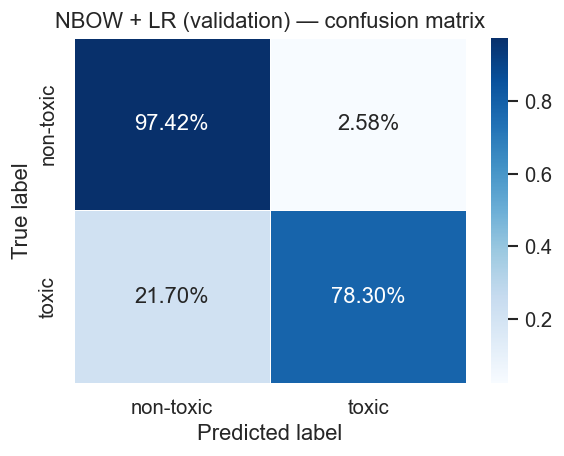

ROC-AUC: 0.9660


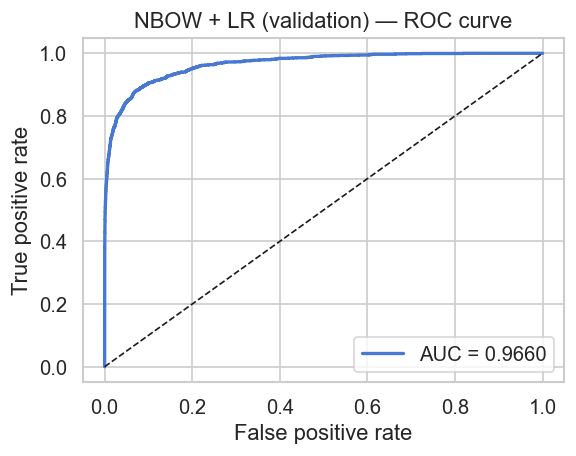

In [16]:
val_preds = best_lr.predict(X_val)
val_probs = best_lr.predict_proba(X_val)[:, 1]

val_results = evaluate(val['label'], val_preds,
                       model_name='NBOW + LR (validation)',
                       y_prob=val_probs)


## 5. Threshold tuning

By default sklearn uses a threshold of 0.5: predict toxic if P(toxic) >= 0.5.
On imbalanced data this is often not optimal. A lower threshold catches more toxic
comments (higher recall) at the cost of more false alarms (lower precision).

We tune the threshold using the **validation set** and apply the best threshold
to the test set. Never tune using test predictions.


Threshold tuning (optimising f1 on validation set):
  Default threshold (0.5): F1=0.7787
  Best threshold (0.89):   F1=0.7854  P=0.8516  R=0.7287
Threshold curve saved to /Users/tuqa/4650/final project/toxic-classification/results/nbow_lr_threshold_curve.png


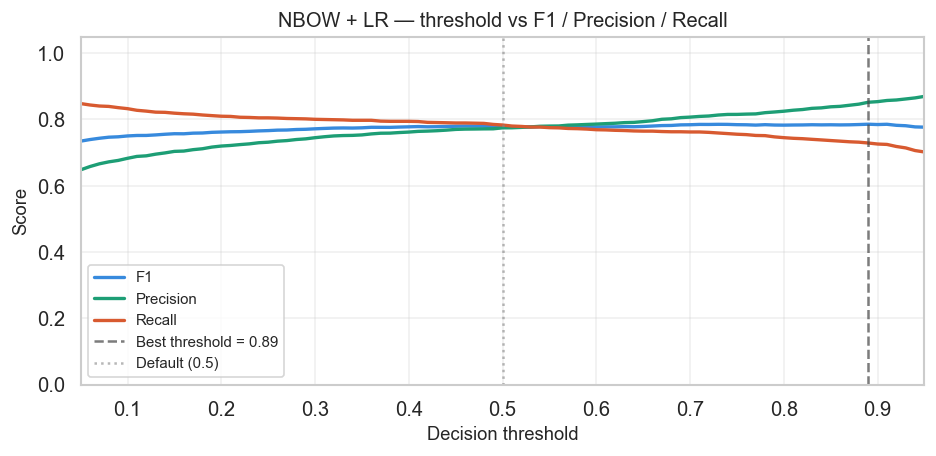

In [17]:
best_threshold, thresh_df = tune_threshold(val['label'], val_probs, metric='f1')
plot_threshold_curve(thresh_df, best_threshold)


In [18]:
# default threshold vs tuned threshold
default_preds = best_lr.predict(X_val)                      # threshold = 0.5
tuned_preds   = (val_probs >= best_threshold).astype(int)

from sklearn.metrics import f1_score, precision_score, recall_score
print(f"Default threshold (0.5):")
print(f"  F1={f1_score(val['label'], default_preds, pos_label=1):.4f}  "
      f"P={precision_score(val['label'], default_preds, pos_label=1):.4f}  "
      f"R={recall_score(val['label'], default_preds, pos_label=1):.4f}")
print()
print(f"Tuned threshold ({best_threshold}):")
print(f"  F1={f1_score(val['label'], tuned_preds, pos_label=1):.4f}  "
      f"P={precision_score(val['label'], tuned_preds, pos_label=1):.4f}  "
      f"R={recall_score(val['label'], tuned_preds, pos_label=1):.4f}")


Default threshold (0.5):
  F1=0.7787  P=0.7744  R=0.7830

Tuned threshold (0.89):
  F1=0.7854  P=0.8516  R=0.7287


## 6. Test set evaluation

> This cell should only be run ONCE — after all decisions (C, threshold) are locked in from the validation set.


  NBOW + LR
              precision    recall  f1-score   support

   non-toxic     0.9714    0.9847    0.9780     14335
       toxic     0.8464    0.7437    0.7917      1623

    accuracy                         0.9602     15958
   macro avg     0.9089    0.8642    0.8849     15958
weighted avg     0.9587    0.9602    0.9591     15958



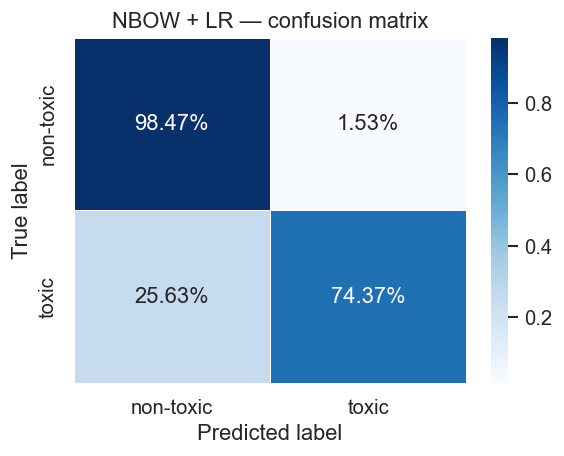

ROC-AUC: 0.9698


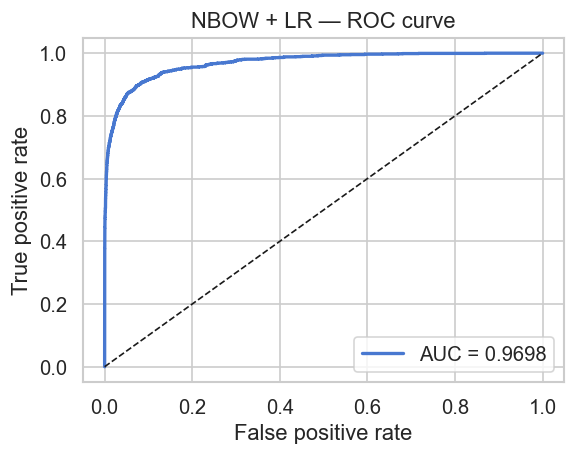

In [19]:
test_probs = best_lr.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

test_results = evaluate(
    test['label'], test_preds,
    model_name='NBOW + LR',
    y_prob=test_probs,
)


## 7. Feature importance

What words and bigrams drive the model's predictions? This directly motivates the error analysis — if surface-level slurs dominate the top features, the model will fail on sarcasm and implicit toxicity.

In [20]:
print_top_features(vectorizer, best_lr, n=25)



  Top 25 features → TOXIC  (positive coefficients)
  fuck                            +132.6852
  fucking                         +119.7706
  shit                            +92.3102
  bullshit                        +87.4944
  idiot                           +82.7210
  bitch                           +76.1961
  stupid                          +76.0695
  ass                             +75.4852
  asshole                         +73.8085
  suck                            +68.1810
  sucks                           +67.3654
  cunt                            +66.2059
  idiots                          +62.9725
  fucked                          +61.2453
  faggot                          +59.8023
  moron                           +59.4114
  penis                           +58.2701
  crap                            +54.7072
  idiotic                         +53.1777
  dick                            +51.8458
  assholes                        +49.2455
  dickhead                        +49.0566


Feature plot saved to /Users/tuqa/4650/final project/toxic-classification/results/nbow_lr_top_features.png


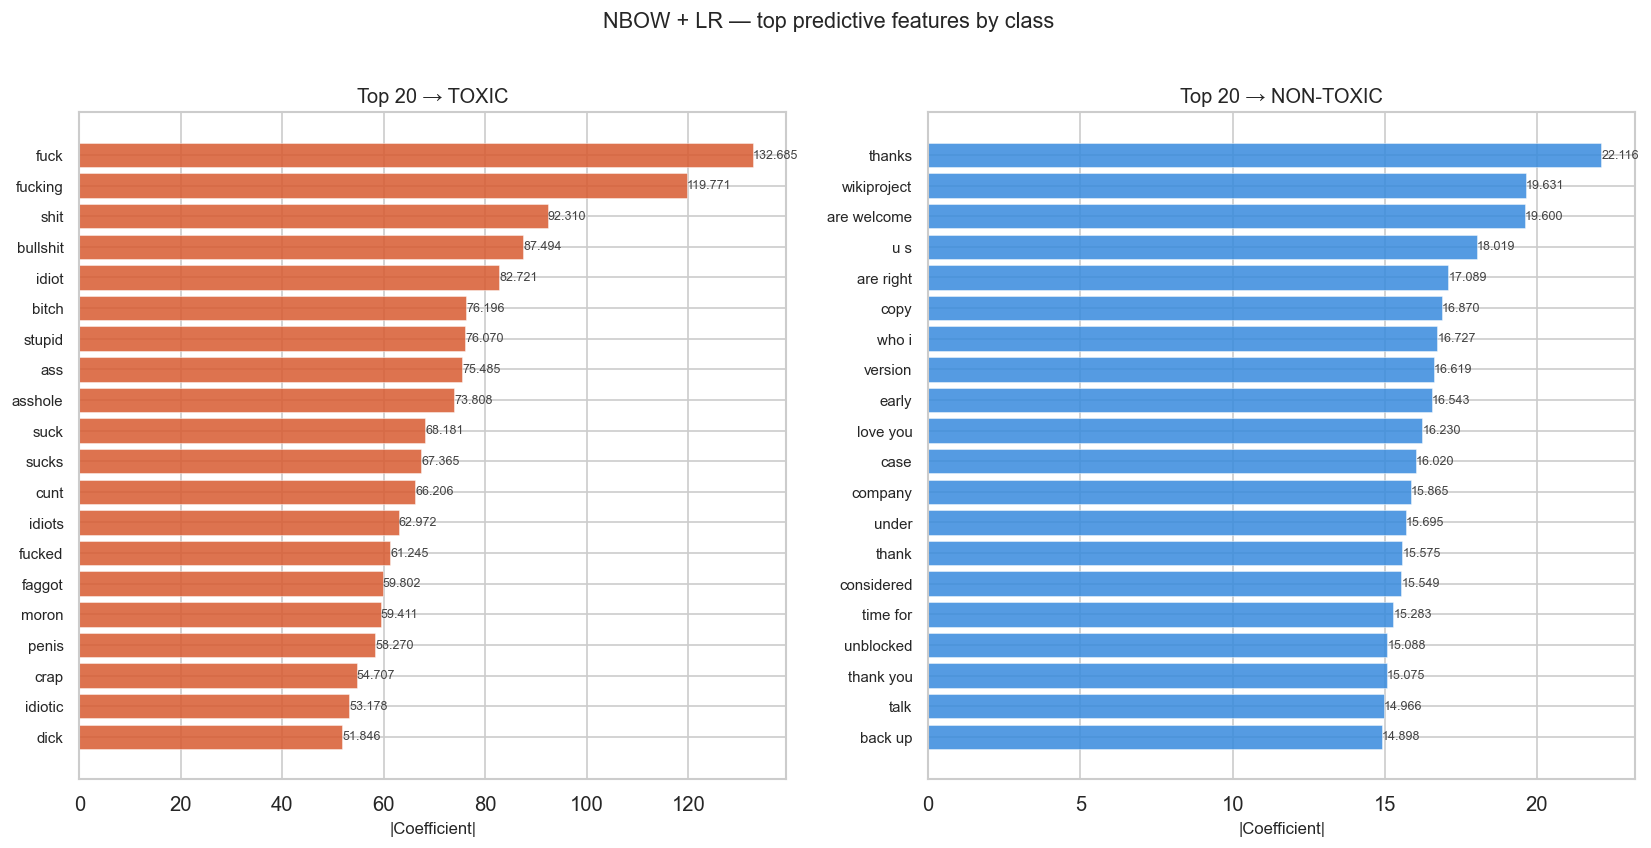

In [21]:
plot_top_features(vectorizer, best_lr, n=20)


In [22]:
# look at top bigrams specifically
toxic_df, nontoxic_df = get_top_features(vectorizer, best_lr, n=200)

print("Top 15 TOXIC bigrams:")
toxic_bigrams = toxic_df[toxic_df['feature'].str.contains(' ')].head(15)
print(toxic_bigrams.to_string(index=False))

print()
print("Top 15 NON-TOXIC bigrams:")
nontoxic_bigrams = nontoxic_df[nontoxic_df['feature'].str.contains(' ')].head(15)
print(nontoxic_bigrams.to_string(index=False))


Top 15 TOXIC bigrams:
      feature  coefficient
     fuck you      34.7035
       a dick      28.2203
     the fuck      26.6446
     death to      24.8342
    fucked up      23.9097
     an idiot      23.6709
   an asshole      21.7464
     fuck off      21.5936
wikipedia has      20.7137
     see also      20.3395
       give a      20.1585
    have ever      19.9196
        are a      19.8473
    talk talk      19.3052
      being a      18.6181

Top 15 NON-TOXIC bigrams:
    feature  coefficient
are welcome     -19.6004
        u s     -18.0193
  are right     -17.0889
      who i     -16.7275
   love you     -16.2298
   time for     -15.2833
  thank you     -15.0753
    back up     -14.8980
   would be     -14.4282
     to ask     -14.3881
    will go     -14.1673
  could you     -14.0774
 you delete     -13.7912
  sorry for     -13.7287
     said i     -13.6170


**Interpretation:** 

The model mostly keys off obvious stuff like “fuck you” or “an idiot,” so it’s good at catching really explicit toxicity but misses more subtle things like sarcasm or indirect insults. It also picks up random phrases like “wikipedia has” or “see also,” which shows it’s just learning patterns from the data instead of actually understanding meaning. Because of that, it both misses some toxic comments and sometimes flags normal, non-toxic text as toxic.


## 8. Ablation study

How much does each design decision contribute to final performance? This section tests removing or changing each component and measuring the impact on validation F1.

In [5]:
print("Running ablation study (this takes ~3-5 minutes) ...")
ablation_df = run_ablation(train, val)

print("\nAblation results:")
print(ablation_df.to_string(index=False))


Running ablation study (this takes ~3-5 minutes) ...
Running baseline grid search for best C ...

Running 5-fold cross-validation over C=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0] ...

Grid search complete.
  Best C     : 1000.0
  Best val F1: 0.7822

Full CV results:
      C  mean_val_f1  std_val_f1  mean_train_f1
   0.01     0.614371    0.005828       0.623355
   0.10     0.675350    0.005953       0.703902
   1.00     0.751121    0.003445       0.836018
  10.00     0.775034    0.004193       0.906982
 100.00     0.778869    0.004964       0.942642
1000.00     0.782151    0.006115       0.933377
Best C: 1000.0


Ablation results:
                                                  config  val_f1   delta
                                     Larger vocab (100k)  0.7826  0.0039
Baseline (bigrams, sublinear, balanced, 50k, clean text)  0.7787  0.0000
                                    Stricter min_df (10)  0.7769 -0.0018
                                       Looser min_df (2)  0.7754 -0.0033


Ablation plot saved to /Users/tuqa/4650/final project/toxic-classification/results/nbow_lr_ablation.png


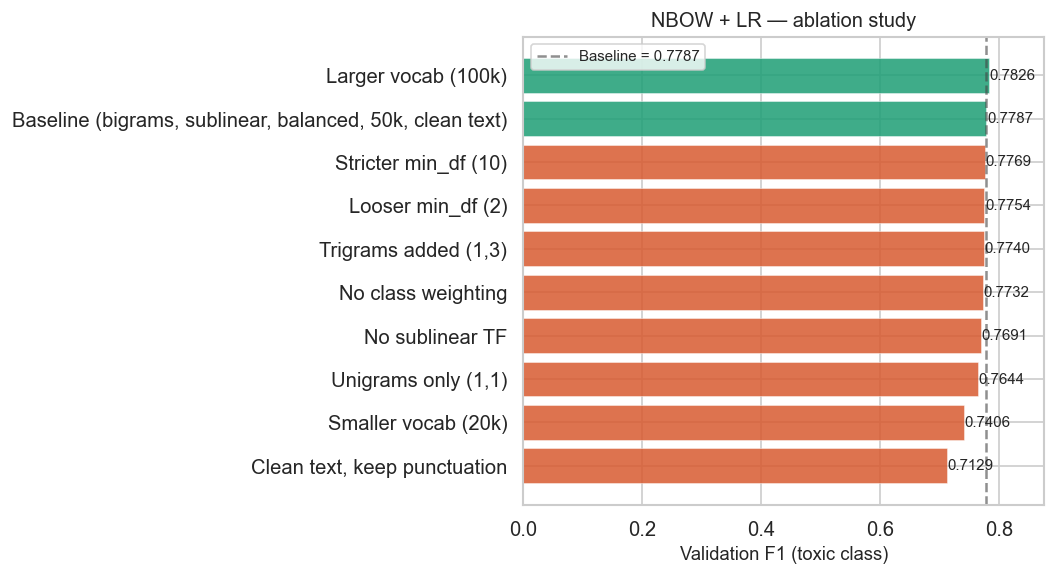

Ablation results saved.


In [7]:
plot_ablation(ablation_df)
ablation_df.to_csv('../results/nbow_lr_ablation.csv', index=False)
print("Ablation results saved.")


Most changes either hurt performance or barely help, which suggests the baseline setup is already pretty solid. The only thing that really improves it is using a larger vocabulary, while things like removing bigrams or class weighting noticeably hurt, showing those choices are important for capturing toxic language.


## 9. Error analysis setup

Extract false positives and false negatives for manual annotation in notebook 06.

In [24]:
test_out = test.copy()
test_out['nbow_lr_pred'] = test_preds
test_out['nbow_lr_prob'] = test_probs.round(6)

errors = extract_errors(test_out, pred_col='nbow_lr_pred', n_samples=50)

errors['false_positives'].to_csv('../results/errors_nbow_fp.csv', index=False)
errors['false_negatives'].to_csv('../results/errors_nbow_fn.csv', index=False)

print("Error samples saved. Open them in error analysis notebook to annotate.")


False positives: 219 total  |  50 sampled
False negatives: 416 total  |  50 sampled
Error samples saved. Open them in error analysis notebook to annotate.


In [25]:
# Preview: what do our worst false negatives look like?
# (toxic comments the model missed — labelled non-toxic)
print("=== FALSE NEGATIVES: toxic comments we missed ===")
fn = test_out[(test_out['label']==1) & (test_out['nbow_lr_pred']==0)]
fn_sorted = fn.sort_values('nbow_lr_prob')  # lowest predicted prob = most confident wrong

pd.set_option('display.max_colwidth', 250)
for _, row in fn_sorted.head(8).iterrows():
    print(f"P(toxic)={row['nbow_lr_prob']:.3f}  |  {row['comment_text'][:200]}")
    print()


=== FALSE NEGATIVES: toxic comments we missed ===
P(toxic)=0.000  |  If something is not acceptable for your bald headed brain doesn't mean it can be unacceptable.

P(toxic)=0.000  |  ... 

Hi, I have no idea what you are babbling about...

P(toxic)=0.000  |  The facts: 
1. This is a blatant lie, as proven here. Your comment dates from . The last version containing non-religious reasons for conversion to islam, which was active around that time, , did not 

P(toxic)=0.000  |  Ooooh, i dunno. He treats those two ladies awfully, slapping them, shoved one in a cupboard, insults them. he's not too bad to major but still condecending.

P(toxic)=0.000  |  "

 re: msg 

you must understand that the sentence in question was originally added as a joke (by me, and i regret that), but later was restructured and even supported with a botched up ""evidence"" 

P(toxic)=0.000  |  "

Also, everything you linked to Dennis Brown, was quite obviously meant as humor. ""ALL I DID WAS TELL THE TRUTH ABOUT 

In [26]:
# Preview: what do our worst false positives look like?
# (non-toxic comments flagged as toxic)
print("=== FALSE POSITIVES: non-toxic comments we flagged ===")
fp = test_out[(test_out['label']==0) & (test_out['nbow_lr_pred']==1)]
fp_sorted = fp.sort_values('nbow_lr_prob', ascending=False)

for _, row in fp_sorted.head(8).iterrows():
    print(f"P(toxic)={row['nbow_lr_prob']:.3f}  |  {row['comment_text'][:200]}")
    print()


=== FALSE POSITIVES: non-toxic comments we flagged ===
P(toxic)=1.000  |  Please 

Please stop being a jerk or you will be blocked.

P(toxic)=1.000  |  LOL PENIS! 

LOL!

I AM TALKING TO YOU SO THIS SHIT IS NOT VANDALISING!

P(toxic)=1.000  |  "
Search Results
Wikipedia Admins Abuse | Jess C Scott : Singapore Politics ...
https://jesscscott.wordpress.com/2010/11/16/wikipedia-admins/
Nov 16, 2010 - I've noticed that a lot of Wiki admins are 

P(toxic)=1.000  |  "
Get a life - you only see what you want to see - par for the course, I don't give a shit, so whatever. 49 hours for the first time I've ever been blocked/warned ... ... Wikipedia's loss, not mine.  

P(toxic)=1.000  |  Khurki is a dumb Assk Jeeves?

P(toxic)=1.000  |  , 5 July 2014 (UTC)
Oh noes. How will I ever recover from you not giving me any respect. Perhaps I'll reflect on the fact that a) you're a total moron who wouldn't know a true benefit to Wikipedia if 

P(toxic)=1.000  |  Your a disgrace Dan stop making up silly st

## 10. Save everything

In [27]:
import json

# Save predictions
test_out.to_csv('../results/test_nbow_lr_preds.csv', index=False)
print("Predictions saved → results/test_nbow_lr_preds.csv")

# Save metrics
test_results['decision_threshold'] = float(best_threshold)
with open('../results/nbow_lr_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print("Results saved     → results/nbow_lr_results.json")

# Save model
save_model(vectorizer, best_lr, models_dir='../models')


Predictions saved → results/test_nbow_lr_preds.csv
Results saved     → results/nbow_lr_results.json
Saved vectorizer → ../models/tfidf_vectorizer.pkl
Saved classifier → ../models/logistic_regression.pkl


In [29]:
# Final sanity check — reload model and confirm predictions match
vec_loaded, lr_loaded = load_model(models_dir='../models')
reload_preds = (lr_loaded.predict_proba(vec_loaded.transform(test['clean_text'].fillna('')))[:, 1] >= best_threshold).astype(int)
assert (reload_preds == test_preds).all(), "Reload mismatch — check save/load"
print("Sanity check passed: reloaded model produces identical predictions.")


Sanity check passed: reloaded model produces identical predictions.


## Summary

| | |
|---|---|
| **Vectorizer** | TF-IDF, unigrams+bigrams, 50k features, sublinear TF |
| **Classifier** | Logistic Regression, class_weight='balanced' |
| **Best C** | 1000 |
| **Decision threshold** | 0.89 |
| **Val F1 (toxic)** | 0.7787 |
| **Test F1 (toxic)** | 0.7917 |
